# Module 9 — Evaluation, Cross-Validation, Pipelines & Grid Search

This is the module that quietly separates hobbyists from professionals. Anyone can
call `.fit()` and print a number. The pro question is harder: **"How do I know this
number is real — and not just luck, or leakage that will vanish the moment the model
meets new data?"**

The answer is a discipline: honest splitting, **cross-validation**, **Pipelines**
that make leakage impossible, and principled **hyperparameter tuning**. Master this
and you'll trust your own results — and be able to defend them.

> 🧠 **Analogy** — Testing a model on the same data it trained on is like grading students with the exact exam they studied — everyone looks brilliant, and you learn nothing about who can handle a NEW question. Cross-validation is giving fresh exams, over and over.

## 9.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV,
                                     RandomizedSearchCV, validation_curve,
                                     learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/customers_clean.csv")
print("loaded:", df.shape)

loaded: (500, 16)


## 9.2 Why one split isn't enough

> 🌱 **In plain English**
>
> A single train/test split gives you exactly ONE noisy number. Change the random
> seed and the score jiggles — sometimes by a lot. Worse: if you keep peeking at the
> *test* set to decide which model or setting is best, you slowly leak its secrets
> into your choices, and your final number becomes an optimistic lie.

The disciplined three-way setup:
- **Train** — fit the model's parameters.
- **Validation** — tune settings and compare models.
- **Test** — touched exactly **once**, at the very end, for an honest final score.

Cross-validation replaces the fragile train/validation part with something far
more stable.

> 📖 **validation set** = data used to tune/compare models — separate from the final test set

> 📖 **data leakage** = when information from outside the training fold sneaks in and inflates the score

## 9.3 k-Fold Cross-Validation — a stable, honest estimate

> 🌱 **In plain English**
>
> Split the training data into k equal chunks ('folds'). Train on k−1 of them,
> validate on the one left out, then rotate so every chunk gets its turn as the
> validator. Average the k scores. Now every row has been used for validation exactly
> once, and you get a mean AND a spread — a far more trustworthy picture than a single
> split. For classification, use **StratifiedKFold** so each fold keeps the same
> class balance.

In [2]:
features_num = ["age", "income", "tenure_months", "monthly_spend", "support_calls"]
X = df[features_num]; y = df["churn"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="f1")
print("F1 per fold:", np.round(scores, 3))
print(f"CV F1 = {scores.mean():.3f} ± {scores.std():.3f}")

F1 per fold: [0.576 0.542 0.557 0.655 0.594]
CV F1 = 0.585 ± 0.039


> 🔤 **Reading the code (line by line)**
>
> - `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` makes 5 balanced,
>   shuffled, reproducible folds.
> - `cross_val_score(...)` runs the fit/score loop 5 times and hands back the 5 scores.
> - We report the MEAN (typical performance) and the STD (how much it wobbles).

> ✅ **Takeaway** — Report performance as mean ± std across folds — never a single number. A large std is itself a finding: it means an unstable model or too little data.

> 🎓 **Go deeper**
>
> Stephen — this is exactly the '80.02% CV accuracy, ±0.29%' line from your DrivenData
> result. The 80.02% is the fold MEAN; the ±0.29% is the fold STD. You were already
> speaking the professional language; now you know precisely what each half means and
> why quoting both is what earns trust on a leaderboard writeup or in an interview.

> 📖 **k-fold cross-validation** = rotate which fold is held out k times, then average the scores

> 📖 **StratifiedKFold** = k-fold that keeps each class's proportion the same in every fold

## 9.4 Pipelines — make leakage structurally impossible

> 🌱 **In plain English**
>
> Here's the trap that catches almost everyone: if you scale or impute using the WHOLE
> dataset before cross-validating, the validation folds have already peeked at their
> own statistics — that's leakage, and your CV score is inflated. A **Pipeline** fixes
> this by bundling preprocessing + model into one object, so every transform is
> re-fit on the training fold ONLY, automatically, on every fold.

> 🧠 **Analogy** — A Pipeline is a sealed assembly line: raw data goes in one end, a prediction comes out the other, and each station (impute → scale → encode → model) only ever calibrates itself on the training material passing through it — never on the test items. You physically can't leak.

In [3]:
num_features = ["age", "income", "tenure_months", "monthly_spend", "support_calls"]
cat_features = ["city", "plan"]

X = df[num_features + cat_features]
y = df["churn"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          random_state=42, stratify=y)

numeric = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
categorical = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocess = ColumnTransformer([
    ("num", numeric,     num_features),
    ("cat", categorical, cat_features),
])

clf = Pipeline([
    ("prep",  preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

clf.fit(X_tr, y_tr)
print("Test F1 (full pipeline):", round(f1_score(y_te, clf.predict(X_te)), 3))

Test F1 (full pipeline): 0.575


> 🔤 **Reading the code (line by line)**
>
> - `ColumnTransformer` routes numeric columns through impute→scale and categorical
>   columns through impute→one-hot — different treatment for different column types.
> - Wrapping it all in one `Pipeline` means `.fit` calibrates every step on train only,
>   and `.predict` reuses those exact fitted transforms. One object, zero leakage.

> 🗣️ **Say this in an interview** — Say this almost verbatim and interviewers relax: 'I wrap preprocessing and the model
in a single scikit-learn Pipeline with a ColumnTransformer. That guarantees every
transform is fit on the training folds only — so leakage is structurally impossible —
and the whole thing deploys as one reusable object.'

> 📖 **Pipeline** = an object chaining preprocessing steps + a model so they fit/predict together

> 📖 **ColumnTransformer** = applies different preprocessing to different groups of columns

## 9.5 GridSearchCV — tuning settings the right way

> 🌱 **In plain English**
>
> Two words people mix up: a **parameter** is learned FROM the data (like a regression
> coefficient); a **hyperparameter** is a knob YOU set BEFORE training (like k in KNN,
> or C in logistic regression, or a tree's depth). GridSearch tries every combination
> of hyperparameters you list, scores each with cross-validation, and reports the
> best — all without ever touching the test set.

In [4]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],       # inverse regularization strength
    "model__penalty": ["l2"],
}
grid = GridSearchCV(clf, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_tr, y_tr)

print("best params:", grid.best_params_)
print("best CV F1 :", round(grid.best_score_, 3))
print("test F1    :", round(f1_score(y_te, grid.predict(X_te)), 3))

best params: {'model__C': 100, 'model__penalty': 'l2'}
best CV F1 : 0.571
test F1    : 0.592


> 🔤 **Reading the code (line by line)**
>
> - The `model__C` syntax means '<pipeline step name>__<that step's parameter>' — it
>   reaches inside the pipeline to tune the model's C.
> - GridSearchCV cross-validates EVERY combination, keeps the best, and refits it on
>   all of the training data. `n_jobs=-1` uses all CPU cores.

> 🌱 **In plain English**
>
> When the grid gets big, exhaustive search explodes combinatorially.
> **RandomizedSearchCV** samples a fixed number of random combinations instead — often
> landing on a near-best setting for a fraction of the cost. Prefer it for many-knob
> models like Random Forest or XGBoost.

In [5]:
from scipy.stats import randint
rf_pipe = Pipeline([("prep", preprocess),
                    ("model", RandomForestClassifier(random_state=42,
                                                     class_weight="balanced"))])
rf_dist = {
    "model__n_estimators":    randint(100, 400),
    "model__max_depth":       randint(3, 15),
    "model__min_samples_leaf": randint(1, 20),
}
rand = RandomizedSearchCV(rf_pipe, rf_dist, n_iter=15, cv=5,
                          scoring="f1", random_state=42, n_jobs=-1)
rand.fit(X_tr, y_tr)
print("best params:", rand.best_params_)
print("best CV F1 :", round(rand.best_score_, 3))
print("test F1    :", round(f1_score(y_te, rand.predict(X_te)), 3))

best params: {'model__max_depth': 12, 'model__min_samples_leaf': 9, 'model__n_estimators': 152}
best CV F1 : 0.55
test F1    : 0.5


> 📖 **hyperparameter** = a setting you choose before training (k, C, tree depth) — not learned from data

> 📖 **GridSearchCV** = tries every hyperparameter combination, scoring each by cross-validation

> 📖 **RandomizedSearchCV** = samples random hyperparameter combinations — cheaper when the grid is huge

## 9.6 Overfitting vs underfitting — see it with curves

> 🌱 **In plain English**
>
> Two failure modes, and you can literally see each one:
> - **Underfitting (high bias)** — model too simple; it's mediocre on BOTH train and
>   validation.
> - **Overfitting (high variance)** — model too complex; brilliant on train, poor on
>   validation, because it memorised noise.
>
> A **validation curve** varies one hyperparameter; a **learning curve** varies the
> amount of training data.

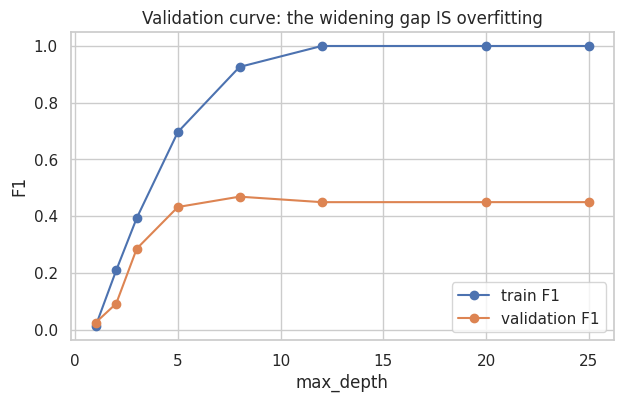

In [6]:
# Validation curve over Random Forest depth (numeric-only for a clean view)
Xn = df[num_features].fillna(df[num_features].median())
depths = [1, 2, 3, 5, 8, 12, 20, None]
depth_vals = [d if d is not None else 25 for d in depths]
train_sc, val_sc = validation_curve(
    RandomForestClassifier(n_estimators=150, random_state=42),
    Xn, y, param_name="max_depth",
    param_range=[d if d is not None else None for d in depths],
    cv=5, scoring="f1", n_jobs=-1)

plt.figure(figsize=(7, 4))
plt.plot(depth_vals, train_sc.mean(1), "o-", label="train F1")
plt.plot(depth_vals, val_sc.mean(1),   "o-", label="validation F1")
plt.xlabel("max_depth"); plt.ylabel("F1")
plt.title("Validation curve: the widening gap IS overfitting"); plt.legend(); plt.show()

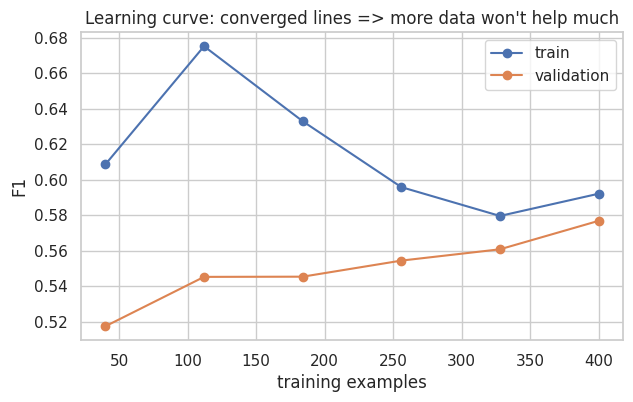

In [7]:
# Learning curve: would MORE data actually help?
sizes, tr_sc, va_sc = learning_curve(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    Xn, y, cv=5, scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)
plt.figure(figsize=(7, 4))
plt.plot(sizes, tr_sc.mean(1), "o-", label="train")
plt.plot(sizes, va_sc.mean(1), "o-", label="validation")
plt.xlabel("training examples"); plt.ylabel("F1")
plt.title("Learning curve: converged lines => more data won't help much")
plt.legend(); plt.show()

> 🔤 **Reading the code (line by line)**
>
> - Validation curve: as depth grows, TRAIN F1 keeps climbing while VALIDATION plateaus
>   then dips — that growing gap is overfitting made visible.
> - Learning curve: if the two lines have converged, collecting more data won't help; if
>   validation is still rising at the right edge, more data probably will.

> 🎓 **Go deeper**
>
> How to ACT on the curves — this is the payoff:
> - Big train-vs-validation gap → overfitting → simplify the model, add regularization,
>   or get more data.
> - Both scores low and close together → underfitting → add features or use a more
>   flexible model.
> - Validation still climbing as data grows → go collect more data, it's worth it.
> Reading these two plots turns 'my model is bad' into a specific, fundable next action.

> 📖 **underfitting** = model too simple: poor on both training and validation data (high bias)

> 📖 **overfitting** = model too complex: great on training, poor on new data (high variance)

## 9.7 Try it yourself

> ✍️ **Try this yourself** — 1. Change `scoring` to 'roc_auc' in the CV and grid search. Do the best params change?
2. Add the imputer strategy to the grid (`num__impute__strategy: ['median','mean']`).
   Which wins?
3. Shrink the training set to 20% and re-plot the learning curve. What happens to the gap?
4. Give one crisp example each of a parameter vs a hyperparameter.

## Summary

> ✅ **Takeaway** — - One split is noisy; **k-fold CV** gives **mean ± std** — always report both.
- **StratifiedKFold** preserves class balance for classification.
- **Pipelines + ColumnTransformer** fold preprocessing into the model → leakage-proof and deployable.
- **GridSearchCV** (exhaustive) / **RandomizedSearchCV** (sampled) tune hyperparameters with CV, never the test set.
- Diagnose **bias/variance** with **validation** and **learning** curves, then act on what they show.

Next: **Module 10 — Trees, Ensembles & Boosting** (Random Forest, Gradient
Boosting, XGBoost) — the models that win most tabular competitions.